In [47]:
# 1.1 Importer les bibliothèques nécessaires

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# 1.2 Charger le dataset

df = pd.read_csv('heart_disease_uci.csv')

# 1.3 Afficher les 5 premières lignes du dataset

print(df.head())


   id  age     sex    dataset  ...        slope   ca               thal num
0   1   63    Male  Cleveland  ...  downsloping  0.0       fixed defect   0
1   2   67    Male  Cleveland  ...         flat  3.0             normal   2
2   3   67    Male  Cleveland  ...         flat  2.0  reversable defect   1
3   4   37    Male  Cleveland  ...  downsloping  0.0             normal   0
4   5   41  Female  Cleveland  ...    upsloping  0.0             normal   0

[5 rows x 16 columns]


In [ ]:
# 1.4 Nombre de patients et de colonnes

n_patients = df.shape[0]
n_colomns = df.shape[1]
print(f"Nombre de patients : {n_patients}")
print(f"Nombre de colomns : {n_colomns}")
print(df.shape)

Nombre de patients : 920
Nombre de colomns : 16
(920, 16)


In [ ]:
# 1.5 Vérification des valeurs nulles

nan = df.isnull().sum()
print(f"Les valeurs nulles par colonnes sont {nan}")
print(f"Le nombre total des valeurs nulles est {nan.sum()}")

Les valeurs nulles par colonnes sont id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
Le nombre total des valeurs nulles est 1759


In [ ]:
# 1.6 Statistiques descriptives du dataset

print(df.describe())

               id         age    trestbps  ...     oldpeak          ca         num
count  920.000000  920.000000  861.000000  ...  858.000000  309.000000  920.000000
mean   460.500000   53.510870  132.132404  ...    0.878788    0.676375    0.995652
std    265.725422    9.424685   19.066070  ...    1.091226    0.935653    1.142693
min      1.000000   28.000000    0.000000  ...   -2.600000    0.000000    0.000000
25%    230.750000   47.000000  120.000000  ...    0.000000    0.000000    0.000000
50%    460.500000   54.000000  130.000000  ...    0.500000    0.000000    1.000000
75%    690.250000   60.000000  140.000000  ...    1.500000    1.000000    2.000000
max    920.000000   77.000000  200.000000  ...    6.200000    3.000000    4.000000

[8 rows x 8 columns]


In [ ]:
# 1.7 Distribution de la varible cible

print(df["num"].value_counts())

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [ ]:
# Dataset non equilibré apres binarisation

df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)
print(df["num"].value_counts())
print(df["num"].value_counts(normalize=True))

num
1    509
0    411
Name: count, dtype: int64
num
1    0.553261
0    0.446739
Name: proportion, dtype: float64


In [ ]:
# 1.8 Suppression de la colonne 'id'

df = df.drop('id', axis=1)

In [ ]:
# 1.9 Convertir la variable num en binaire

df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
# 1.10 Remplacer les valeurs manquantes par NaN

values = ['?', 'NA', 'NaN', 'nan', 'null', '', ' ', '!', 'None', '.', 'NULL', None]
df.replace(values, np.nan, inplace=True)

nan = df.isnull().sum()
print(f"Les valeurs nulles par colonnes sont {nan}")
print(f"Le nombre total des valeurs nulles est {nan.sum()}")

Les valeurs nulles par colonnes sont age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
Le nombre total des valeurs nulles est 1759


In [13]:
valeurs_manquantes = df.isna().sum()
colonnes_avec_nan = valeurs_manquantes[valeurs_manquantes > 0]
if len(colonnes_avec_nan) > 0:
    for col, count in colonnes_avec_nan.items():
        pct = (count / len(df)) * 100
        print(f"  {col}: {count} ({pct:.2f}%)")
else:
    print("  Aucune valeur manquante")

  trestbps: 59 (6.41%)
  chol: 30 (3.26%)
  fbs: 90 (9.78%)
  restecg: 2 (0.22%)
  thalch: 55 (5.98%)
  exang: 55 (5.98%)
  oldpeak: 62 (6.74%)
  slope: 309 (33.59%)
  ca: 611 (66.41%)
  thal: 486 (52.83%)


In [ ]:
# 1.10 (a) Suppression des lignes avec des valeurs manquantes

nb_lignes_avant = len(df)
df1 = df.dropna()
nb_lignes_apres = len(df1)
print(f"Nombre de lignes avant suppression: {nb_lignes_avant}")
print(f"Nombre de lignes après suppression: {nb_lignes_apres}")

df1.to_csv('heart_disease_uci_sans_nan.csv', index=False)

Nombre de lignes avant suppression: 920
Nombre de lignes après suppression: 299


In [15]:
# 1.10 (b) Imputation des valeurs manquantes avec la moyenne

from sklearn.impute import SimpleImputer

imputer_cat = SimpleImputer(strategy='most_frequent')
imputer_num = SimpleImputer(strategy='mean')
df2 = df.copy()

colonnes_quantitatives = df.select_dtypes(include=['number']).columns
colonnes_categorielles = df.select_dtypes(include=['object']).columns

if df[colonnes_quantitatives].isna().any().any():
    df2[colonnes_quantitatives] = imputer_num.fit_transform(df2[colonnes_quantitatives])
    print("Imputation des colonnes quantitatives effectuée.")

if df[colonnes_categorielles].isna().any().any():
    df2[colonnes_categorielles] = imputer_cat.fit_transform(df2[colonnes_categorielles])
    print("Imputation des colonnes catégorielles effectuée.")

print(f"Nombre de lignes avec imputation : {len(df2)}")
df2.to_csv('heart_disease_uci_imputed.csv', index=False)

Imputation des colonnes quantitatives effectuée.
Imputation des colonnes catégorielles effectuée.
Nombre de lignes avec imputation : 920


In [23]:
# 1.11 Gerer les collonnes categorielles 

df = df2.copy()

colonnes_cat = df.select_dtypes(include=['object']).columns.tolist()
nb_colonnes_avant = df.shape[1]

for col in colonnes_cat :
    nb_uniques = df[col].nunique()
    print(f'for {col} nombres de valeurs uniques : {nb_uniques} ')

df3 = pd.get_dummies(df, columns=colonnes_cat, drop_first=True)
nb_colonnes_apres = df3.shape[1]

print(f"\n Nombre de colonnes avant one hot encoding :{nb_colonnes_avant}")
print(f" Nombre de colonnes apres one hot encoding :{nb_colonnes_apres}")
df3.to_csv('heart_disease_uci_onehotencoding.csv', index=False)

for sex nombres de valeurs uniques : 2 
for dataset nombres de valeurs uniques : 4 
for cp nombres de valeurs uniques : 4 
for fbs nombres de valeurs uniques : 2 
for restecg nombres de valeurs uniques : 3 
for exang nombres de valeurs uniques : 2 
for slope nombres de valeurs uniques : 3 
for thal nombres de valeurs uniques : 3 

 Nombre de colonnes avant one hot encoding :15
 Nombre de colonnes apres one hot encoding :22


In [24]:
# 1.12 Conversion des types de données en float

colomns = df3.columns.tolist()

colomns.remove('num')

df3[colomns] = df3[colomns].astype(float)

df3.to_csv('heart_disease_uci_onehotencoding.csv', index=False)

In [25]:
# 3.1 Séparation les features X et la target y

df = df3.copy()

y = df['num']
X = df.drop('num', axis=1)


In [76]:
# 3.2 Division du dataset en ensembles d'entraînement et de test

X_train,  X_test, y_train,  y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

train_indices = y_train.index
test_indices = y_test.index


print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}") 

X_train : (736, 21)
y_train : (736,)


In [77]:
# 3.3 Normalisation les données avec StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nStatistiques AVANT normalisation (X_train):")
print(f"  - Moyenne: {X_train.mean().mean():.4f}")
print(f"  - Écart-type: {X_train.std().mean():.4f}")
print(f"\nStatistiques APRÈS normalisation (X_train_scaled):")
print(f"  - Moyenne: {X_train_scaled.mean():.4f}")
print(f"  - Écart-type: {X_train_scaled.std():.4f}")


Statistiques AVANT normalisation (X_train):
  - Moyenne: 25.2729
  - Écart-type: 8.0292

Statistiques APRÈS normalisation (X_train_scaled):
  - Moyenne: 0.0000
  - Écart-type: 1.0000


In [78]:
# 3.4 Conersion des données en tenseurs PyTorch

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

In [79]:
# 3.5 Dimensions finales des tenseurs
print(f"\nDimensions finales des tenseurs :")
print(f"  - X_train: {X_train.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - X_test: {X_test.shape}")
print(f"  - y_test: {y_test.shape}")


Dimensions finales des tenseurs :
  - X_train: torch.Size([736, 21])
  - y_train: torch.Size([736])
  - X_test: torch.Size([184, 21])
  - y_test: torch.Size([184])


In [ ]:
# 4.1 Architecture du modèle de réseau de neurones

class HeartDiseaseNN(nn.Module):
   def __init__(self, input_dim):
      super(HeartDiseaseNN, self). __init__()

      self.fc1 = nn.Linear(input_dim, 32)
      self.relu1 = nn.ReLU()

      self.fc2 = nn.Linear(32,16)
      self.relu2 = nn.ReLU()

      self.output = nn.Linear(16,2)

   def forward(self, x):
      x = self.fc1(x)
      x = self.relu1(x)

      x = self.fc2(x)
      x = self.relu2(x)

      x = self.output(x)
      return x


input_dim = X_train.shape[1]
model = HeartDiseaseNN(input_dim)
print(f"\nNombre total de paramètres: `{sum(p.numel() for p in model.parameters())}`")
print("\nDétail du modèle:")
print(model)


Nombre total de paramètres: `1266`

Détail du modèle:
HeartDiseaseNN(
  (fc1): Linear(in_features=21, out_features=32, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=16, out_features=2, bias=True)
)


In [81]:
# 4.2 Definition de la fonction de perte et de l'optimiseur

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [82]:
# 5.1 Entraînement du modèle pour 100 époques

N_EPOCHS = 100

train_losses = []
train_accuracies = []

for epoch in range(N_EPOCHS):
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()
    
    optimizer.step()

    _, predicted = torch.max(outputs, 1)
    total = y_train.size(0)
    correct = (predicted == y_train).sum().item()
    accuracy = 100 * correct / total

    train_losses.append(loss.item())
    train_accuracies.append(accuracy)

# 5.2 Affichage de la perte et de l'exactitude toutes les 10 époques

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{N_EPOCHS}], Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')


Epoch [10/100], Loss: 0.6468, Accuracy: 68.61%
Epoch [20/100], Loss: 0.6106, Accuracy: 76.09%
Epoch [30/100], Loss: 0.5664, Accuracy: 78.80%
Epoch [40/100], Loss: 0.5155, Accuracy: 80.57%
Epoch [50/100], Loss: 0.4663, Accuracy: 81.52%
Epoch [60/100], Loss: 0.4258, Accuracy: 82.47%
Epoch [70/100], Loss: 0.3967, Accuracy: 83.42%
Epoch [80/100], Loss: 0.3764, Accuracy: 84.24%
Epoch [90/100], Loss: 0.3625, Accuracy: 84.92%
Epoch [100/100], Loss: 0.3521, Accuracy: 85.46%



✓ Graphiques sauvegardés: 'training_curves.png'


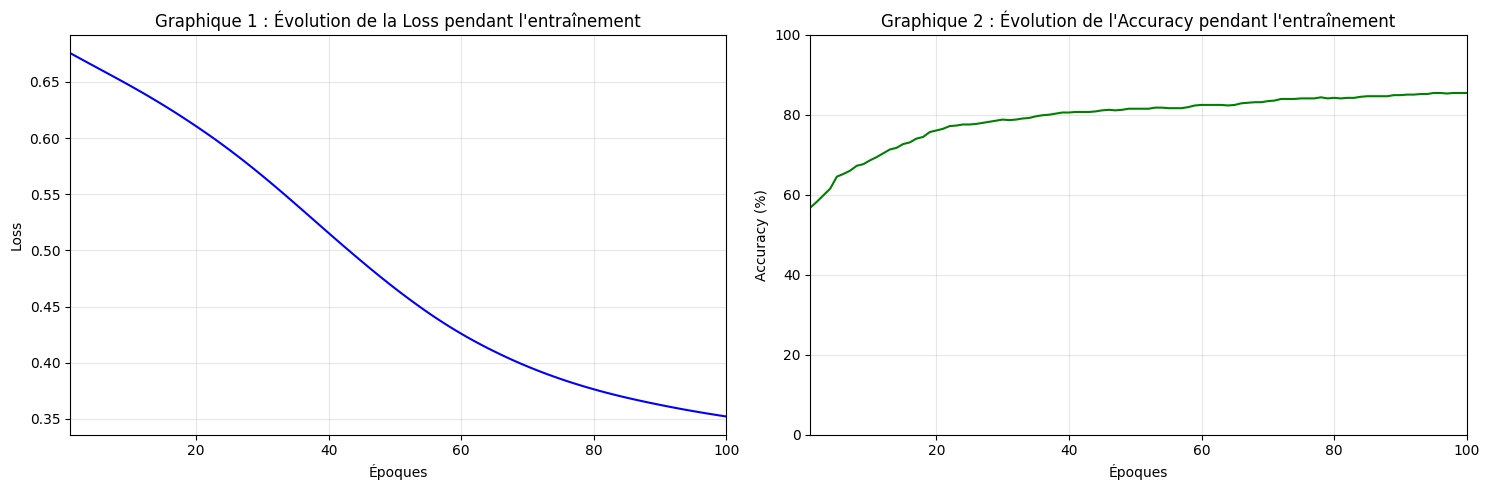

In [83]:
# 5.3 Deux graphiques : -1) Evolution de la loss -2) Evolution de l'accuracy

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Graphe 1 : Evolution de la loss

ax1.plot(range(1, N_EPOCHS + 1), train_losses, label='Loss', color='blue')
ax1.set_title('Graphique 1 : Évolution de la Loss pendant l\'entraînement')
ax1.set_xlabel('Époques')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, N_EPOCHS)

        # Graphe 2 : Evolution de l'accuracy
        
ax2.plot(range(1, N_EPOCHS + 1), train_accuracies, label='Accuracy', color='green')
ax2.set_title('Graphique 2 : Évolution de l\'Accuracy pendant l\'entraînement')
ax2.set_xlabel('Époques')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, N_EPOCHS)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
print("\n✓ Graphiques sauvegardés: 'training_curves.png'")
plt.show()

In [84]:
# 6.1 Predictions sur l'ensemble de test 

model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    _, test_predicted = torch.max(test_outputs, 1)

print(f"Nombre d'échantillons testés: {len(test_predicted)}")


Nombre d'échantillons testés: 184


In [85]:
# 6.2 Calcul de l accuracy sur l ensemble de test

test_correct = (test_predicted == y_test).sum().item()
total_test = y_test.size(0)
accuracy_test = 100 * test_correct / total_test
print(f"Accuracy sur l'ensemble de test: {accuracy_test:.2f}%")   

Accuracy sur l'ensemble de test: 84.78%


In [86]:
# 6.3 Afficher le classification report

print("Classification Report:")
print(classification_report(y_test, test_predicted))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82        82
           1       0.83      0.91      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184




✓ Matrice de confusion sauvegardée: 'confusion_matrix.png'


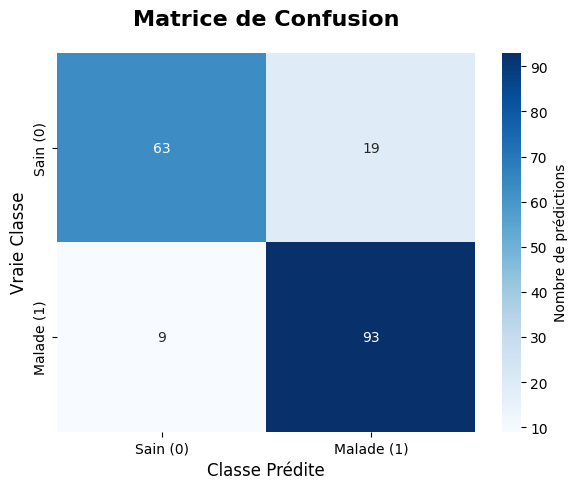

In [87]:
# 6.4 Matrice de confusion
import seaborn as sns


cm = confusion_matrix(y_test, test_predicted)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sain (0)', 'Malade (1)'],
            yticklabels=['Sain (0)', 'Malade (1)'],
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title('Matrice de Confusion', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie Classe', fontsize=12)
plt.xlabel('Classe Prédite', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n✓ Matrice de confusion sauvegardée: 'confusion_matrix.png'")
plt.show()

In [88]:
# 7.1 Model lineaire avec une seule couche

class LinearModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearModel, self).__init__()
        self.fc = nn.Linear(input_dim, 2)

    def forward(self, x):
        x = self.fc(x)
        return x
    
input_dim = X_train.shape[1]
model_linear = LinearModel(input_dim)
print(f"\nNombre total de paramètres pour le modèle linéaire: {sum(p.numel() for p in model_linear.parameters())}")


Nombre total de paramètres pour le modèle linéaire: 44


In [89]:
# 7.2 Entraînement du modèle linéaire avec les memes hyperparamètres

criterion_linear = nn.CrossEntropyLoss()
optimizer_linear = optim.Adam(model_linear.parameters(), lr=0.001)

linear_losses = []
linear_accuracies = []


for epoch in range(N_EPOCHS):
    model_linear.train()

    optimizer_linear.zero_grad()

    outputs_linear = model_linear(X_train)

    loss_linear = criterion_linear(outputs_linear, y_train)

    loss_linear.backward()
    
    optimizer_linear.step()

    _, predicted_linear = torch.max(outputs_linear, 1)
    total = y_train.size(0)
    correct_linear = (predicted_linear == y_train).sum().item()
    accuracy_linear = 100 * correct_linear / total

    linear_losses.append(loss_linear.item())
    linear_accuracies.append(accuracy_linear)


    if (epoch+1) % 10 == 0:
        print(f'Linear Model - Epoch [{epoch+1}/{N_EPOCHS}], Loss: {loss_linear.item():.4f}, Accuracy: {accuracy_linear:.2f}%')

Linear Model - Epoch [10/100], Loss: 0.7583, Accuracy: 52.99%
Linear Model - Epoch [20/100], Loss: 0.7176, Accuracy: 56.39%
Linear Model - Epoch [30/100], Loss: 0.6814, Accuracy: 58.97%
Linear Model - Epoch [40/100], Loss: 0.6495, Accuracy: 61.82%
Linear Model - Epoch [50/100], Loss: 0.6218, Accuracy: 64.27%
Linear Model - Epoch [60/100], Loss: 0.5978, Accuracy: 65.49%
Linear Model - Epoch [70/100], Loss: 0.5770, Accuracy: 67.26%
Linear Model - Epoch [80/100], Loss: 0.5589, Accuracy: 69.16%
Linear Model - Epoch [90/100], Loss: 0.5430, Accuracy: 69.57%
Linear Model - Epoch [100/100], Loss: 0.5290, Accuracy: 71.88%


In [91]:
# 7.3 Évaluation du modèle linéaire sur l'ensemble de test

model_linear.eval()
with torch.no_grad():
    test_outputs_linear = model_linear(X_test)
    _, test_predicted_linear = torch.max(test_outputs_linear, 1)


print(f"Nombre d'échantillons testés: {len(test_predicted_linear)}")

Nombre d'échantillons testés: 184


In [92]:
# 7.4 Calcul de l accuracy sur l ensemble de test du modèle linéaire

test_correct_linear = (test_predicted_linear == y_test).sum().item()
total_test = y_test.size(0)
accuracy_test_linear = 100 * test_correct_linear / total_test
print(f"Accuracy sur l'ensemble de test: {accuracy_test_linear:.2f}%")   

Accuracy sur l'ensemble de test: 72.83%


In [93]:
#  7.4 Afficher le classification report du modele linéaire

print("Classification Report:")
print(classification_report(y_test, test_predicted_linear))

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.68      0.69        82
           1       0.75      0.76      0.76       102

    accuracy                           0.73       184
   macro avg       0.72      0.72      0.72       184
weighted avg       0.73      0.73      0.73       184




✓ Matrice de confusion sauvegardée: 'confusion_matrix.png'


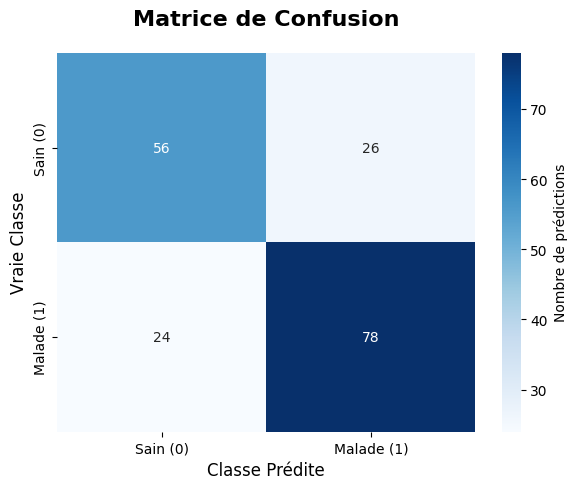

In [94]:
# 7.4 Afficher la matrice de confusion du modèle linéaire

cm_linear = confusion_matrix(y_test, test_predicted_linear)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sain (0)', 'Malade (1)'],
            yticklabels=['Sain (0)', 'Malade (1)'],
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title('Matrice de Confusion', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie Classe', fontsize=12)
plt.xlabel('Classe Prédite', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n✓ Matrice de confusion sauvegardée: 'confusion_matrix.png'")
plt.show()

In [96]:
df_with_predictions = pd.read_csv('heart_disease_uci.csv')
df_with_predictions['num'] = df_with_predictions['num'].apply(lambda x: 1 if x > 0 else 0)
df_with_predictions['MLP_prediction'] = None
df_with_predictions['Linear_prediction'] = None

model.eval()
with torch.no_grad():
    # Prédictions sur le train set
    mlp_train_outputs = model(X_train)
    _, mlp_train_predicted = torch.max(mlp_train_outputs, 1)
    
    # Prédictions sur le test set
    mlp_test_outputs = model(X_test)
    _, mlp_test_predicted = torch.max(mlp_test_outputs, 1)

print(f"  - Train predictions: {len(mlp_train_predicted)}")
print(f"  - Test predictions: {len(mlp_test_predicted)}")


model_linear.eval()
with torch.no_grad():
    # Prédictions sur le train set
    linear_train_outputs = model_linear(X_train)
    _, linear_train_predicted = torch.max(linear_train_outputs, 1)
    
    # Prédictions sur le test set
    linear_test_outputs = model_linear(X_test)
    _, linear_test_predicted = torch.max(linear_test_outputs, 1)

print(f"  - Train predictions: {len(linear_train_predicted)}")
print(f"  - Test predictions: {len(linear_test_predicted)}")




df_with_predictions.loc[train_indices, 'MLP_prediction'] = mlp_train_predicted.numpy()
df_with_predictions.loc[test_indices, 'MLP_prediction'] = mlp_test_predicted.numpy()

df_with_predictions.loc[train_indices, 'Linear_prediction'] = linear_train_predicted.numpy()
df_with_predictions.loc[test_indices, 'Linear_prediction'] = linear_test_predicted.numpy()

df_with_predictions.to_csv('heart_disease_uci_with_predictions.csv', index=False)


  - Train predictions: 736
  - Test predictions: 184
  - Train predictions: 736
  - Test predictions: 184


In [ ]:
# Modification 1 : Modifier les hyperparamètres du modèle

class HeartDiseaseNN_2(nn.Module):
    def __init__(self, input_dim):
        super(HeartDiseaseNN_2, self).__init__()
        
        self.fc1 = nn.Linear(input_dim, 32)
        self.relu1 = nn.ReLU()
        
        self.fc2 = nn.Linear(32, 16)
        self.relu2 = nn.ReLU()
        
        self.output = nn.Linear(16, 2)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        
        x = self.fc2(x)
        x = self.relu2(x)

        
        x = self.output(x)
        return x

# Créer le modèle
input_dim = X_train.shape[1]
model_v2 = HeartDiseaseNN_2(input_dim)

# Hyperparamètres non identiques pour comparer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_v2.parameters(), lr=0.0001)
N_EPOCHS = 200

# Entraînement du modèle 
train_losses_v2 = []
train_accuracies_v2 = []

for epoch in range(N_EPOCHS):
    model_v2.train()
    optimizer.zero_grad()
    outputs = model_v2(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    _, predicted = torch.max(outputs, 1)
    total = y_train.size(0)
    correct = (predicted == y_train).sum().item()
    accuracy = 100 * correct / total
    train_losses_v2.append(loss.item())
    train_accuracies_v2.append(accuracy)


# Évaluation du modèle 
model_v2.eval()
with torch.no_grad():
    test_outputs_v2 = model_v2(X_test)
    _, test_predicted_v2 = torch.max(test_outputs_v2, 1)


print("\nClassification Report:")
print(classification_report(y_test, test_predicted_v2))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.38      0.53        82
           1       0.66      0.96      0.78       102

    accuracy                           0.70       184
   macro avg       0.77      0.67      0.66       184
weighted avg       0.76      0.70      0.67       184



In [165]:

class HeartDiseaseNN_3(nn.Module):
    def __init__(self, input_dim):
        super(HeartDiseaseNN_3, self).__init__()

        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 32)
        self.relu3 = nn.ReLU()

        self.fc4 = nn.Linear(32, 16)
        self.relu4 = nn.ReLU()

        self.output = nn.Linear(16, 2)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)
        x = self.relu3(x)

        x = self.fc4(x)
        x = self.relu4(x)

        x = self.output(x)
        return x

# Créer le modèle
input_dim = X_train.shape[1]
model_v3 = HeartDiseaseNN_3(input_dim)

# Hyperparamètres IDENTIQUES pour comparer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_v3.parameters(), lr=0.001)
N_EPOCHS = 100

# Entraînement du modèle avec 3 couches cachees
train_losses_v3 = []
train_accuracies_v3 = []

for epoch in range(N_EPOCHS):
    model_v3.train()
    optimizer.zero_grad()
    outputs = model_v3(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

_, predicted = torch.max(outputs, 1)
total = y_train.size(0)
correct = (predicted == y_train).sum().item()
accuracy = 100 * correct / total
train_losses_v3.append(loss.item())
train_accuracies_v3.append(accuracy)


# Évaluation du modèle avec 3 couches cachees sur l'ensemble de test
model_v3.eval()
with torch.no_grad():
    test_outputs_v3 = model_v3(X_test)
    _, test_predicted_v3 = torch.max(test_outputs_v3, 1)


print("\nClassification Report:")
print(classification_report(y_test, test_predicted_v3))
       
 


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82        82
           1       0.84      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184

